Company Sales Prediction

In [55]:
import pandas as pd 
import matplotlib.pyplot as mlt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [56]:
df =pd.read_csv("C:\\Users\\LENOVO\\Desktop\\Javascript\\dataset\\CS_Electric_Product_Sales_Practice_Dataset.csv")
df.head()

,Date,Year,Month,Product,Category,Region,Distributor,Price,Discount_%,Marketing_Spend,Festival,Stock_Available,Previous_Month_Sales,Units_Sold,Revenue
0,2024-01-01,2024,1,MCB,Switchgear,South,Bright Power,188.23,0,97397,0,2228,527,502,94491.46
1,2024-01-01,2024,1,MCCB,Switchgear,North,Bright Power,3136.79,0,93563,0,1314,257,300,941037.00
2,2024-01-01,2024,1,ACB,Switchgear,West,Bright Power,42352.68,10,20851,0,1153,212,213,9021120.84
3,2024-01-01,2024,1,Busbar,Power Distribution,East,ElectroHub,11642.55,10,33396,0,879,579,564,6566398.20
4,2024-01-01,2024,1,Distribution Board,Distribution,East,ElectroHub,3599.70,0,115647,0,2381,340,380,1367886.00


In [57]:
df.isnull().sum()

Date                    0
Year                    0
Month                   0
Product                 0
Category                0
Region                  0
Distributor             0
Price                   0
Discount_%              0
Marketing_Spend         0
Festival                0
Stock_Available         0
Previous_Month_Sales    0
Units_Sold              0
Revenue                 0
dtype: int64

In [58]:
df.columns

Index(['Date', 'Year', 'Month', 'Product', 'Category', 'Region', 'Distributor',
       'Price', 'Discount_%', 'Marketing_Spend', 'Festival', 'Stock_Available',
       'Previous_Month_Sales', 'Units_Sold', 'Revenue'],
      dtype='object')

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  144 non-null    object 
 1   Year                  144 non-null    int64  
 2   Month                 144 non-null    int64  
 3   Product               144 non-null    object 
 4   Category              144 non-null    object 
 5   Region                144 non-null    object 
 6   Distributor           144 non-null    object 
 7   Price                 144 non-null    float64
 8   Discount_%            144 non-null    int64  
 9   Marketing_Spend       144 non-null    int64  
 10  Festival              144 non-null    int64  
 11  Stock_Available       144 non-null    int64  
 12  Previous_Month_Sales  144 non-null    int64  
 13  Units_Sold            144 non-null    int64  
 14  Revenue               144 non-null    float64
dtypes: float64(2), int64(8)

In [60]:
df.describe()

,Year,Month,Price,Discount_%,Marketing_Spend,Festival,Stock_Available,Previous_Month_Sales,Units_Sold,Revenue
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,1.440000e+02
mean,2024.500000,6.500000,10680.698194,7.534722,69999.930556,0.250000,1716.034722,546.194444,591.368056,5.383751e+06
std,0.501745,3.464102,14811.316554,5.702304,28831.554925,0.434524,721.602911,217.794549,250.562688,6.546449e+06
min,2024.000000,1.000000,172.020000,0.000000,20336.000000,0.000000,508.000000,212.000000,212.000000,4.572216e+04
25%,2024.000000,3.750000,2255.665000,3.750000,47265.000000,0.000000,1152.750000,391.250000,410.750000,1.129111e+06
50%,2024.500000,6.500000,3426.780000,5.000000,65272.500000,0.000000,1672.500000,514.500000,548.000000,2.076737e+06
75%,2025.000000,9.250000,12235.480000,15.000000,95717.750000,0.250000,2328.750000,643.250000,690.500000,8.635286e+06
max,2025.000000,12.000000,45069.790000,15.000000,118430.000000,1.000000,2986.000000,1515.000000,1664.000000,2.991303e+07


In [61]:
df["Product"].unique()

array(['MCB', 'MCCB', 'ACB', 'Busbar', 'Distribution Board', 'Contactor'],
      dtype=object)

In [62]:
df["Category"].unique()


array(['Switchgear', 'Power Distribution', 'Distribution', 'Control'],
      dtype=object)

In [63]:
from sklearn.preprocessing import LabelEncoder

In [64]:
df.columns

Index(['Date', 'Year', 'Month', 'Product', 'Category', 'Region', 'Distributor',
       'Price', 'Discount_%', 'Marketing_Spend', 'Festival', 'Stock_Available',
       'Previous_Month_Sales', 'Units_Sold', 'Revenue'],
      dtype='object')

In [65]:
categorical_col =["Product","Category","Region","Distributor"]

In [66]:
le =LabelEncoder()
for col in categorical_col:
    df[col]=le.fit_transform(df[col])


In [67]:
df.drop(columns=["Year","Month"],axis=1)

,Date,Product,Category,Region,Distributor,Price,Discount_%,Marketing_Spend,Festival,Stock_Available,Previous_Month_Sales,Units_Sold,Revenue
0,2024-01-01,4,3,2,1,188.23,0,97397,0,2228,527,502,94491.46
1,2024-01-01,5,3,1,1,3136.79,0,93563,0,1314,257,300,941037.00
2,2024-01-01,0,3,3,1,42352.68,10,20851,0,1153,212,213,9021120.84
3,2024-01-01,1,2,0,2,11642.55,10,33396,0,879,579,564,6566398.20
4,2024-01-01,3,1,0,2,3599.70,0,115647,0,2381,340,380,1367886.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,2025-12-01,5,3,0,0,3446.82,15,55976,0,533,931,953,3284819.46
140,2025-12-01,0,3,1,3,44447.30,10,50162,0,2986,619,673,29913032.90
141,2025-12-01,1,2,2,1,12368.59,5,102345,0,897,1153,1313,16239958.67
142,2025-12-01,3,1,1,2,3683.82,0,95965,0,1994,1515,1664,6129876.48


In [68]:
df["Date"]=pd.to_datetime(df["Date"])
df["day"]=df["Date"].dt.day
df["month"]=df["Date"].dt.month
df["year"]=df["Date"].dt.year
df.drop(columns=["Date"])

,Year,Month,Product,Category,Region,Distributor,Price,Discount_%,Marketing_Spend,Festival,Stock_Available,Previous_Month_Sales,Units_Sold,Revenue,day,month,year
0,2024,1,4,3,2,1,188.23,0,97397,0,2228,527,502,94491.46,1,1,2024
1,2024,1,5,3,1,1,3136.79,0,93563,0,1314,257,300,941037.00,1,1,2024
2,2024,1,0,3,3,1,42352.68,10,20851,0,1153,212,213,9021120.84,1,1,2024
3,2024,1,1,2,0,2,11642.55,10,33396,0,879,579,564,6566398.20,1,1,2024
4,2024,1,3,1,0,2,3599.70,0,115647,0,2381,340,380,1367886.00,1,1,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,2025,12,5,3,0,0,3446.82,15,55976,0,533,931,953,3284819.46,1,12,2025
140,2025,12,0,3,1,3,44447.30,10,50162,0,2986,619,673,29913032.90,1,12,2025
141,2025,12,1,2,2,1,12368.59,5,102345,0,897,1153,1313,16239958.67,1,12,2025
142,2025,12,3,1,1,2,3683.82,0,95965,0,1994,1515,1664,6129876.48,1,12,2025


In [69]:
df.columns

Index(['Date', 'Year', 'Month', 'Product', 'Category', 'Region', 'Distributor',
       'Price', 'Discount_%', 'Marketing_Spend', 'Festival', 'Stock_Available',
       'Previous_Month_Sales', 'Units_Sold', 'Revenue', 'day', 'month',
       'year'],
      dtype='object')

In [70]:
df.dtypes

Date                    datetime64[ns]
Year                             int64
Month                            int64
Product                          int64
Category                         int64
Region                           int64
Distributor                      int64
Price                          float64
Discount_%                       int64
Marketing_Spend                  int64
Festival                         int64
Stock_Available                  int64
Previous_Month_Sales             int64
Units_Sold                       int64
Revenue                        float64
day                              int32
month                            int32
year                             int32
dtype: object

In [71]:
df.head()

,Date,Year,Month,Product,Category,Region,Distributor,Price,Discount_%,Marketing_Spend,Festival,Stock_Available,Previous_Month_Sales,Units_Sold,Revenue,day,month,year
0,2024-01-01,2024,1,4,3,2,1,188.23,0,97397,0,2228,527,502,94491.46,1,1,2024
1,2024-01-01,2024,1,5,3,1,1,3136.79,0,93563,0,1314,257,300,941037.00,1,1,2024
2,2024-01-01,2024,1,0,3,3,1,42352.68,10,20851,0,1153,212,213,9021120.84,1,1,2024
3,2024-01-01,2024,1,1,2,0,2,11642.55,10,33396,0,879,579,564,6566398.20,1,1,2024
4,2024-01-01,2024,1,3,1,0,2,3599.70,0,115647,0,2381,340,380,1367886.00,1,1,2024


In [72]:
X =df.drop(["Units_Sold","Date","Revenue"],axis=1)
y =df["Units_Sold"]

In [73]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [74]:
#model =XGBRegressor(n_estimators=150,max_depth=3,random_state=42,learning_rate=0.05,enable_categorical=True)

In [75]:
model = XGBRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=2,
    random_state=42
)

In [76]:
model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=150,
             n_jobs=None, num_parallel_tree=None, ...)

In [77]:
print(type(model))

<class 'xgboost.sklearn.XGBRegressor'>


In [78]:
y_pred =model.predict(X_test)
X_test

,Year,Month,Product,Category,Region,Distributor,Price,Discount_%,Marketing_Spend,Festival,Stock_Available,Previous_Month_Sales,day,month,year
117,2025,8,1,2,0,3,12375.64,0,46680,0,1593,692,1,8,2025
19,2024,4,5,3,2,0,3075.63,15,29071,0,2681,396,1,4,2024
82,2025,2,3,1,3,3,3753.37,5,29961,0,2925,633,1,2,2025
97,2025,5,5,3,0,0,3334.54,5,55954,0,686,385,1,5,2025
56,2024,10,0,3,1,1,41888.65,0,107062,1,1852,302,1,10,2024
12,2024,3,4,3,3,3,179.47,5,86784,1,2521,512,1,3,2024
132,2025,11,4,3,1,3,174.89,10,23794,1,688,493,1,11,2025
65,2024,11,2,0,2,1,2319.98,15,26582,1,2783,570,1,11,2024
66,2024,12,4,3,1,3,174.12,15,107500,0,2675,916,1,12,2024
18,2024,4,4,3,1,2,182.43,0,67576,0,1759,554,1,4,2024


In [79]:
from sklearn.metrics import mean_absolute_error,r2_score

In [80]:
mae =mean_absolute_error(y_test,y_pred)
r2 =r2_score(y_test,y_pred)
print(mae)
print(r2)

42.47345733642578
0.9092715382575989


In [81]:
print("test score",model.score(X_train,y_train))
print("test score",model.score(X_test,y_test))

test score 0.9925364255905151
test score 0.9092715382575989


In [82]:
df.head()

,Date,Year,Month,Product,Category,Region,Distributor,Price,Discount_%,Marketing_Spend,Festival,Stock_Available,Previous_Month_Sales,Units_Sold,Revenue,day,month,year
0,2024-01-01,2024,1,4,3,2,1,188.23,0,97397,0,2228,527,502,94491.46,1,1,2024
1,2024-01-01,2024,1,5,3,1,1,3136.79,0,93563,0,1314,257,300,941037.00,1,1,2024
2,2024-01-01,2024,1,0,3,3,1,42352.68,10,20851,0,1153,212,213,9021120.84,1,1,2024
3,2024-01-01,2024,1,1,2,0,2,11642.55,10,33396,0,879,579,564,6566398.20,1,1,2024
4,2024-01-01,2024,1,3,1,0,2,3599.70,0,115647,0,2381,340,380,1367886.00,1,1,2024


In [83]:
pred =model.predict([[2025,1,4,2,0,2,11642.55,10,33396,0,879,579,1,1,2024]])

In [84]:
pred

array([586.26776], dtype=float32)

In [85]:
new_data = pd.DataFrame({
    "Year":[2024],
    "Month":[1],
    "Product":[0],
    "Category":[3],
    "Region":[3],
    "Distributor":[1],
    "Price":[42352.68],
    "Discount_%":[10],
    "Marketing_Spend":[20851],
    "Festival":[0],
    "Stock_Available":[1153],
    "Previous_Month_Sales":[212],
    "day":[1],
    "month":[1],
    "year":[2024]
})

In [86]:
new_data.head(2)

,Year,Month,Product,Category,Region,Distributor,Price,Discount_%,Marketing_Spend,Festival,Stock_Available,Previous_Month_Sales,day,month,year
0,2024,1,0,3,3,1,42352.68,10,20851,0,1153,212,1,1,2024


In [87]:
pred2 =model.predict(new_data)
pred2

array([228.18263], dtype=float32)

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

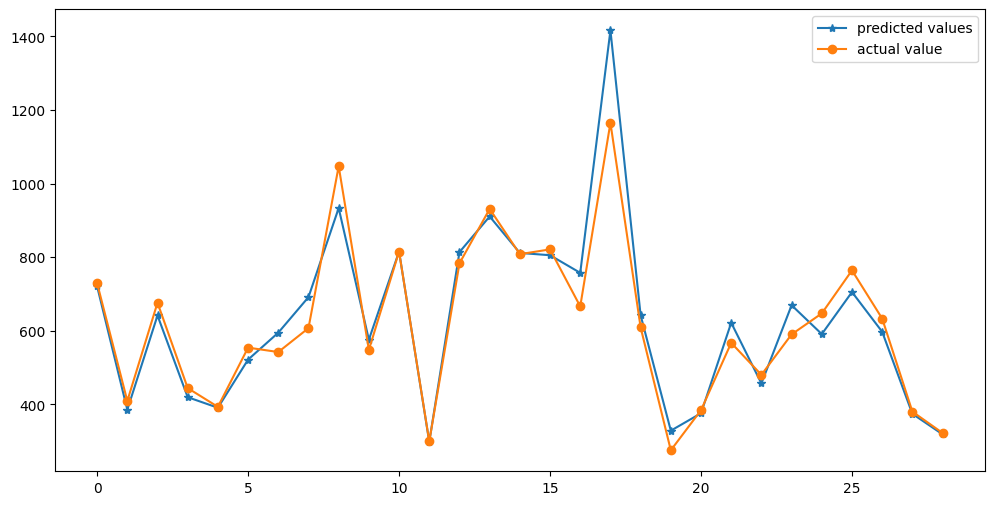

In [89]:
figure =plt.figure(figsize=(12,6))
plt.plot(y_pred,label="predicted values",marker="*")
plt.plot(y_test.values,label="actual value",marker="o")

plt.legend()
plt.show()

In [90]:
y_test.count()

np.int64(29)

In [91]:
test_data =pd.read_csv("C:\\Users\\LENOVO\\Desktop\\Javascript\\dataset\\test_CS_Electric_29_Test_Values.csv")
test_data.head()

,Year,Month,Product,Category,Region,Distributor,Price,Discount_%,Marketing_Spend,Festival,Stock_Available,Previous_Month_Sales,day,month,year
0,2025,1,0,3,2,1,42500.50,10,25000,0,1200,215,1,1,2025
1,2025,2,1,3,0,2,3180.75,5,30000,0,1500,240,1,2,2025
2,2025,3,2,3,1,3,41800.00,15,85000,1,2800,450,1,3,2025
3,2025,4,3,2,3,0,11850.25,0,18000,0,1700,190,1,4,2025
4,2025,5,4,1,2,2,3550.00,8,42000,0,2100,265,1,5,2025


In [92]:
pred3 =model.predict(test_data)
pred3

array([244.71368, 259.1308 , 488.18854, 298.6668 , 327.63556, 288.82675,
       325.25058, 385.2088 , 552.365  , 710.93024, 384.1685 , 493.56586,
       275.6253 , 382.98834, 546.9338 , 335.95612, 300.5767 , 348.6971 ,
       403.22925, 434.7366 , 549.5249 , 783.42285, 406.02136, 500.78656,
       291.3795 , 407.96393, 594.57153, 325.05954, 296.46857],
      dtype=float32)

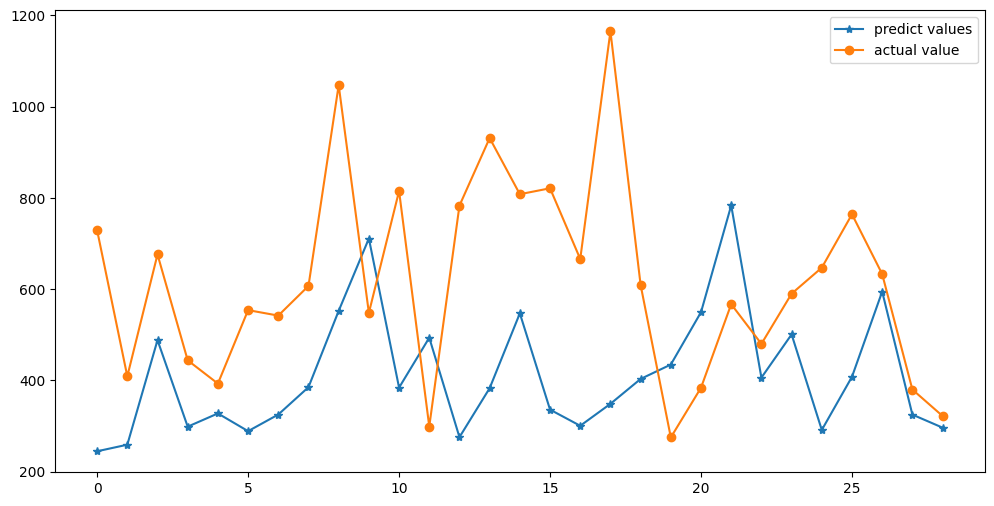

In [93]:
figure=plt.figure(figsize=(12,6))
plt.plot(pred3,label="predict values",marker="*")
plt.plot(y_test.values,label="actual value",marker="o")
plt.legend()
plt.show()

In [106]:
pred3_r2 =r2_score(y_test,pred3)
pred3_r2

-1.2699601650238037

In [95]:
model2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

In [96]:
model2.fit(X_train,y_train)

RandomForestRegressor(max_depth=8, max_features='sqrt', min_samples_leaf=4,
                      min_samples_split=10, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [97]:
pred_rd =model2.predict(X_test)

In [101]:
m =mean_absolute_error(y_test,pred_rd)
r =r2_score(y_test,pred_rd)

print(m)
print(r)

67.43531770565424
0.8392173814589298


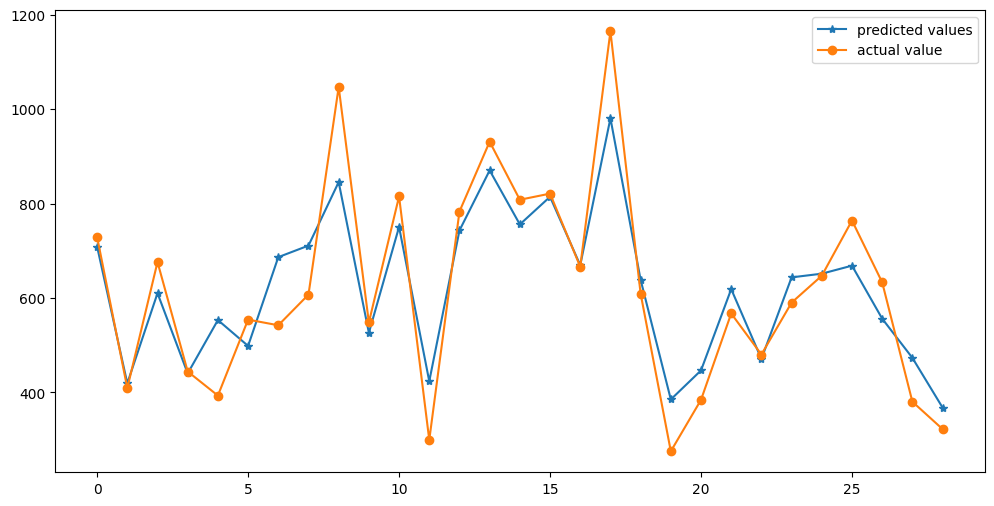

In [102]:
figure =plt.figure(figsize=(12,6))
plt.plot(pred_rd,label="predicted values",marker="*")
plt.plot(y_test.values,label="actual value",marker="o")

plt.legend()
plt.show()

In [103]:
pred_test =model2.predict(test_data)

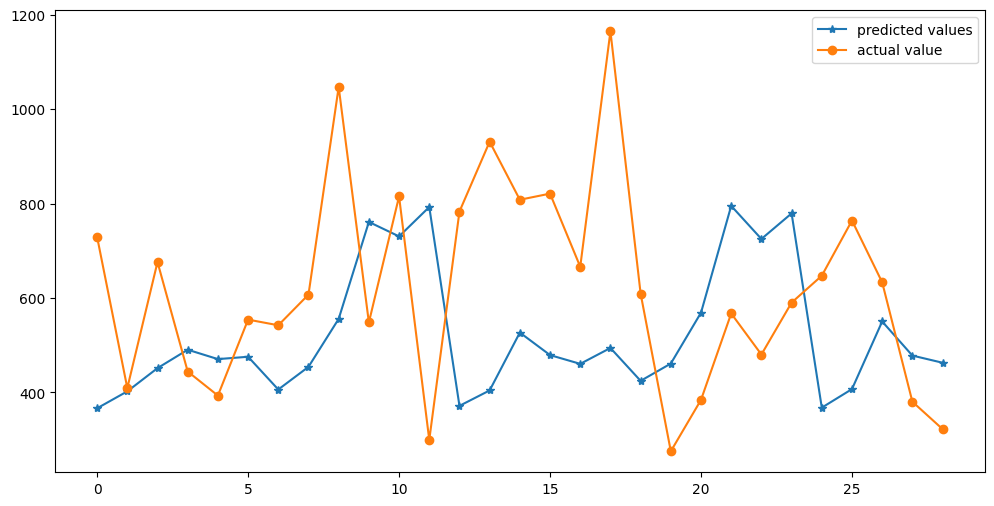

In [104]:
figure =plt.figure(figsize=(12,6))
plt.plot(pred_test,label="predicted values",marker="*")
plt.plot(y_test.values,label="actual value",marker="o")

plt.legend()
plt.show()

In [105]:
test_r2=r2_score(y_test,pred_test)
test_r2


-0.7877255339312526